Heart Disease Dataset Analysis

This project explores patient demographics, heart disease distribution, and data quality issues in the Heart Disease dataset. The goal is to understand who is represented in the dataset, identify suspicious or missing values, and prepare the data for reliable analysis.

In [118]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [119]:
#Load Data Function
def load_data(file_path):
    """
    Loads a CSV file and returns a DataFrame.
    Handles missing files and empty CSV files.
    """
    try:
        df = pd.read_csv(file_path)
        print(f"Data loaded successfully. DataFrame shape: {df.shape}")
        return df
    
    except FileNotFoundError:
        print(f"File not found at: {file_path}")
    
    except pd.errors.EmptyDataError:
        print("The CSV file is empty.")

In [120]:
#Test Error Handling
load_data("wrong.csv")

File not found at: wrong.csv


In [121]:
#Load Actual Dataset
df = load_data("../data/heart.csv")
df.head()

Data loaded successfully. DataFrame shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 1. Data Overview

This section reviews the dataset shape, first few rows, column types, summary statistics, and category distributions.

In [122]:
#Basic Preview
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [123]:
#Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [124]:
#Summary Statistics
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [125]:
#Category Value Counts
categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for Sex:
Sex
M    725
F    193
Name: count, dtype: int64

Value counts for ChestPainType:
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

Value counts for RestingECG:
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

Value counts for ExerciseAngina:
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

Value counts for ST_Slope:
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


- **Age**: patient age in years.
- **Sex**: patient sex, recorded as M for male and F for female.
- **ChestPainType**: type of chest pain experienced by the patient.
- **RestingBP**: resting blood pressure measured in mm Hg.
- **Cholesterol**: serum cholesterol measured in mg/dL.
- **FastingBS**: fasting blood sugar indicator, where 1 means fasting blood sugar is greater than 120 mg/dL and 0 means otherwise.
- **RestingECG**: resting electrocardiogram result.
- **MaxHR**: maximum heart rate achieved during testing.
- **ExerciseAngina**: exercise-induced angina, recorded as Y for yes and N for no.
- **Oldpeak**: ST depression induced by exercise relative to rest.
- **ST_Slope**: slope of the peak exercise ST segment.
- **HeartDisease**: target variable, where 1 indicates heart disease and 0 indicates no heart disease.

The numeric columns are Age, RestingBP, Cholesterol, FastingBS, MaxHR, Oldpeak, and HeartDisease; the categorical object columns are Sex, ChestPainType, RestingECG, ExerciseAngina, and ST_Slope.

## 2. Data Quality Investigation

The minimum values of Cholesterol and RestingBP are 0, which is biologically impossible for living patients. This suggests these zeros are not real measurements but disguised missing values recorded as 0 instead of being left blank.

In [126]:
#Check Impossible Zero Values
zero_cholesterol = df["Cholesterol"] == 0
zero_restingbp = df["RestingBP"] == 0

print(f"Patients with zero Cholesterol: {zero_cholesterol.sum()}")
print(f"Patients with zero RestingBP: {zero_restingbp.sum()}")

print(f"Percentage with zero Cholesterol: {zero_cholesterol.mean():.1%}")
print(f"Percentage with zero RestingBP: {zero_restingbp.mean():.1%}")

Patients with zero Cholesterol: 172
Patients with zero RestingBP: 1
Percentage with zero Cholesterol: 18.7%
Percentage with zero RestingBP: 0.1%


In [127]:
#Compare Disease Rates
heart_disease = df["HeartDisease"] == 1

overall_disease_rate = heart_disease.mean()
zero_chol_disease_rate = df.loc[zero_cholesterol, "HeartDisease"].mean()

print(f"Overall HeartDisease rate: {overall_disease_rate:.1%}")
print(f"Total patients with HeartDisease: {heart_disease.sum()}")
print(f"Disease rate among zero-cholesterol patients: {zero_chol_disease_rate:.1%}")

Overall HeartDisease rate: 55.3%
Total patients with HeartDisease: 508
Disease rate among zero-cholesterol patients: 88.4%


Dropping zero-cholesterol records is unsafe because this group is 88.4% diseased. Removing these rows would eliminate nearly 30% of all diseased cases and bias the dataset toward healthier patients.

In [128]:
#Clean Data


df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)

df = df.dropna(subset=["RestingBP"])

median_cholesterol = df["Cholesterol"].median()
df["Cholesterol"] = df["Cholesterol"].fillna(median_cholesterol)

print(f"Cleaned DataFrame shape: {df.shape}")
print(f"Median Cholesterol used for imputation: {median_cholesterol}")

Cleaned DataFrame shape: (917, 12)
Median Cholesterol used for imputation: 237.0


In [129]:
#Validate Cleaning
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000
mean,53.509269,132.540894,243.211559,0.233370,136.789531,0.886696,0.552890
std,9.437636,17.999749,53.430044,0.423206,25.467129,1.066960,0.497466
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,237.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [130]:
#Check Duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


## 3. Q1 — Who is in this dataset?

This section examines patient age, sex distribution, and heart disease balance to understand the population represented in the dataset.

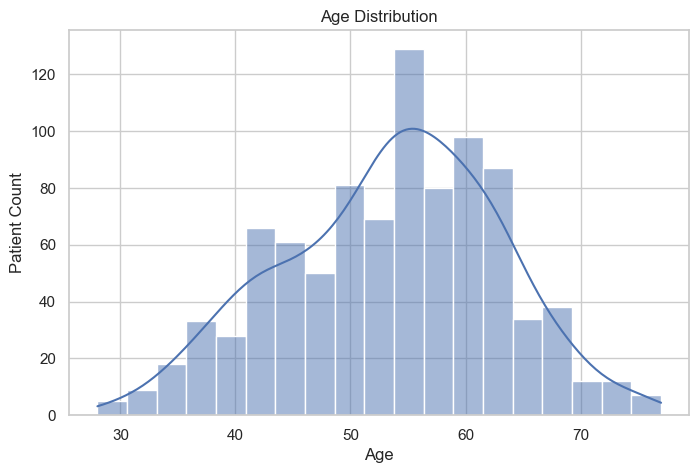

In [131]:
#Age Distribution Chart
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Patient Count")
plt.show()

In [132]:
# Age Summary
df["Age"].describe()

count    917.000000
mean      53.509269
std        9.437636
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64

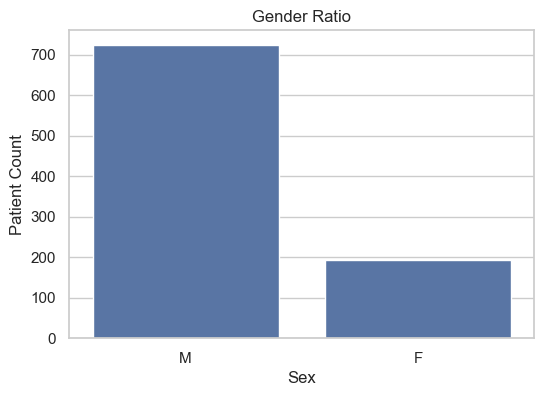

In [133]:
#Gender Ratio Chart
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sex")
plt.title("Gender Ratio")
plt.xlabel("Sex")
plt.ylabel("Patient Count")
plt.show()

In [134]:
#Gender Counts and Percentages
sex_counts = df["Sex"].value_counts()
sex_percentages = df["Sex"].value_counts(normalize=True) * 100

gender_summary = pd.DataFrame({
    "Count": sex_counts,
    "Percentage": sex_percentages.round(1)
})

gender_summary

,Count,Percentage
Sex,,
M,724,79.0
F,193,21.0


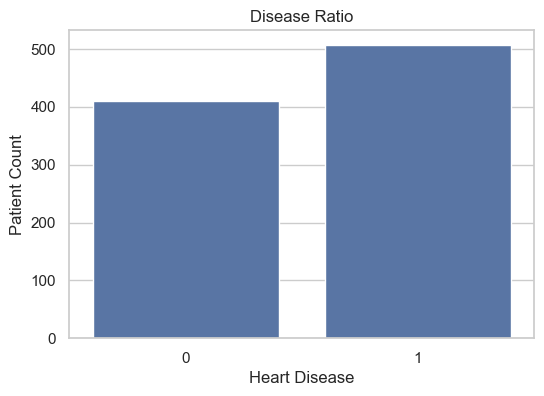

In [135]:
#Disease Ratio Chart
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="HeartDisease")
plt.title("Disease Ratio")
plt.xlabel("Heart Disease")
plt.ylabel("Patient Count")
plt.show()

In [136]:
#Disease Counts and Percentages
disease_counts = df["HeartDisease"].value_counts()
disease_percentages = df["HeartDisease"].value_counts(normalize=True) * 100

disease_summary = pd.DataFrame({
    "Count": disease_counts,
    "Percentage": disease_percentages.round(1)
})

disease_summary

,Count,Percentage
HeartDisease,,
1,507,55.3
0,410,44.7


The dataset includes adult patients from ages 28 to 77, with most patients falling between 47 and 60 years old and a median age of 54.

Male patients make up 724 of 917 records, or 79.0%, while female patients make up 193 records, or 21.0%.

Heart disease is present in 507 of 917 patients, or 55.3%, while 410 patients are healthy, making the target variable fairly balanced.

A key limitation is that about 79% of the dataset is male, so findings from this dataset may not generalize well to female patients.

In [137]:
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


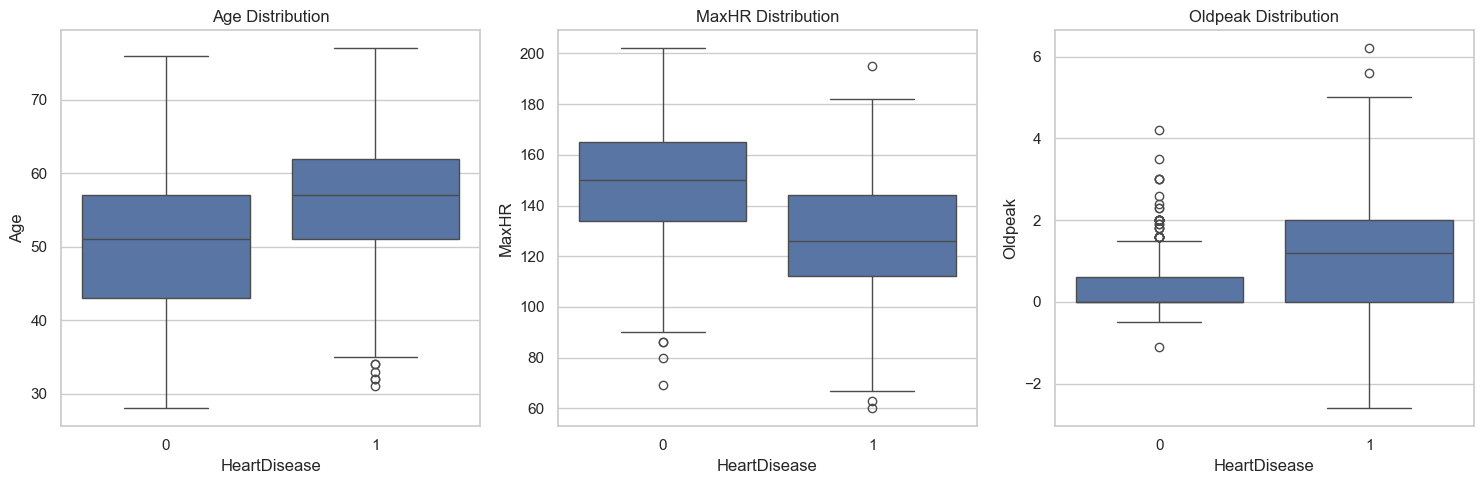

In [148]:

fig,axes=plt.subplots(1,3,figsize=(15,5))



sns.boxplot(df,y='Age',x='HeartDisease',ax=axes[0])
axes[0].set_title("Age Distribution")
axes[0].set_ylabel("Age")
axes[0].set_xlabel("HeartDisease")
sns.boxplot(df,y='MaxHR',x='HeartDisease',ax=axes[1])
axes[1].set_title("MaxHR Distribution")
axes[1].set_ylabel("MaxHR")
axes[1].set_xlabel("HeartDisease")
sns.boxplot(df,y='Oldpeak',x='HeartDisease',ax=axes[2])
axes[2].set_title("Oldpeak Distribution")
axes[2].set_ylabel("Oldpeak")
axes[2].set_xlabel("HeartDisease")
plt.tight_layout()
plt.show()

### Q1 Verdict: Age, MaxHR, and Oldpeak by Heart Disease Status

The diseased group (`HeartDisease = 1`) skews older than the healthy group (`HeartDisease = 0`), with a higher median age and most diseased patients concentrated in older age ranges.

The diseased group has a lower maximum heart rate (`MaxHR`) compared with the healthy group, suggesting patients with heart disease generally achieved lower peak heart rates during testing.

The diseased group shows higher `Oldpeak` values, meaning they had greater ST depression during exercise, which is more strongly associated with heart disease.

Overall, older age, lower maximum heart rate, and higher ST depression appear to be important patterns separating diseased and healthy patients in this dataset.

In [ ]:
cols=['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
k=df.groupby('HeartDisease')[cols].mean()
print(k)


                    Age   RestingBP  Cholesterol       MaxHR   Oldpeak
HeartDisease                                                          
0             50.551220  130.180488   238.682927  148.151220  0.408049
1             55.901381  134.449704   246.873767  127.601578  1.273767


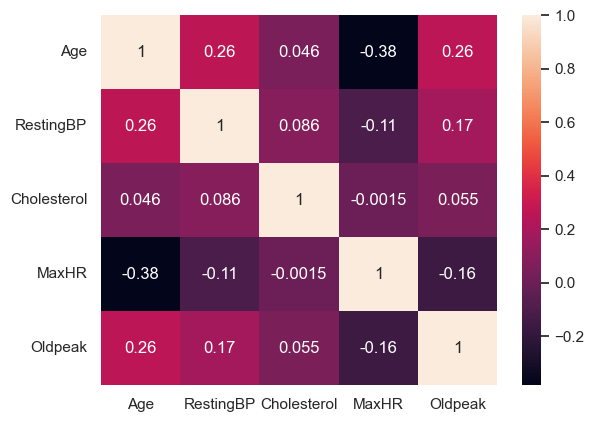

In [160]:
sns.heatmap(df[cols].corr(),annot=True)
plt.show()

### Q2 Verdict: Top Numeric Signals
The clearest numeric signals separating sick and healthy patients are **MaxHR**, **Oldpeak**, and **Age**. Diseased patients have much lower maximum heart rate on average, **127.6 vs. 148.2**, a difference of about **20.5 bpm**, making **MaxHR** the strongest separator.
**Oldpeak** is the second strongest signal because diseased patients show higher ST depression, **1.27 vs. 0.41**, a difference of about **0.87**. **Age** ranks third because diseased patients are older on average, **55.9 vs. 50.6 years**, while the heatmap also shows MaxHR moving negatively against Age and Oldpeak.